# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [3]:
apple = pd.read_csv(r"https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv")

### Step 3. Assign it to a variable apple and apply a head()

In [4]:
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [5]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

In [6]:
apple.describe()

,Open,High,Low,Close,Volume,Adj Close
count,8465.000000,8465.000000,8465.000000,8465.000000,8.465000e+03,8465.000000
mean,98.593926,99.848683,97.226790,98.549199,9.391214e+07,11.095014
std,141.965350,143.155674,140.548326,141.877244,8.993202e+07,21.133016
min,11.120000,11.120000,11.000000,11.000000,2.504000e+05,0.170000
25%,25.750000,26.000000,25.120000,25.630000,3.704960e+07,0.900000
50%,40.750000,41.500000,40.000000,40.750000,6.636000e+07,1.410000
75%,79.500000,81.000000,78.740000,80.000000,1.177701e+08,8.660000
max,702.410000,705.070000,699.570000,702.100000,1.855410e+09,96.280000


### Step 5. Transform the Date column as a datetime type and check the info()

In [7]:
apple['Date'] = pd.to_datetime(apple['Date'])

In [8]:
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [9]:
apple.info()

<class 'pandas.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       8465 non-null   datetime64[us]
 1   Open       8465 non-null   float64       
 2   High       8465 non-null   float64       
 3   Low        8465 non-null   float64       
 4   Close      8465 non-null   float64       
 5   Volume     8465 non-null   int64         
 6   Adj Close  8465 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 463.1 KB


### Step 6.  Set the date as the index

In [10]:
apple.set_index(['Date'], inplace=True)
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 7.  Is there any duplicate dates?

In [11]:
apple.sort_index().loc['2014' : '2025']

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-01-02,555.68,557.03,552.02,553.13,58671200,78.11
2014-01-03,552.86,553.70,540.43,540.98,98116900,76.40
2014-01-06,537.45,546.80,533.60,543.93,103152700,76.81
2014-01-07,544.32,545.96,537.92,540.04,79302300,76.26
2014-01-08,538.81,545.56,538.69,543.46,64632400,76.75
...,...,...,...,...,...,...
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03


In [17]:
apple.index.duplicated().sum()

np.int64(0)

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [12]:
apple.sort_index(ascending=True, inplace=True)
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


### Step 9. Get the last business day of each month

In [13]:
df_ultimo_dia_habil = apple.resample('BME').last()
print(df_ultimo_dia_habil.head())

             Open   High    Low  Close    Volume  Adj Close
Date                                                       
1980-12-31  34.25  34.25  34.13  34.13   8937600       0.53
1981-01-30  28.50  28.50  28.25  28.25  11547200       0.44
1981-02-27  26.50  26.75  26.50  26.50   3690400       0.41
1981-03-31  24.75  24.75  24.50  24.50   3998400       0.38
1981-04-30  28.38  28.62  28.38  28.38   3152800       0.44


### Step 10.  What is the difference in days between the first day and the oldest

In [14]:
# Restar el último índice menos el primero
diferencia = apple.index.max() - apple.index.min()

# Extraer solo el número de días
print(f"La diferencia es de {diferencia.days} días.")

La diferencia es de 12261 días.


### Step 11.  How many months in the data we have?

In [15]:
# Contar combinaciones únicas de Año-Mes
total_meses = apple.index.to_period('M').nunique()

print(f"Hay un total de {total_meses} meses en el dataset.")

Hay un total de 404 meses en el dataset.


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

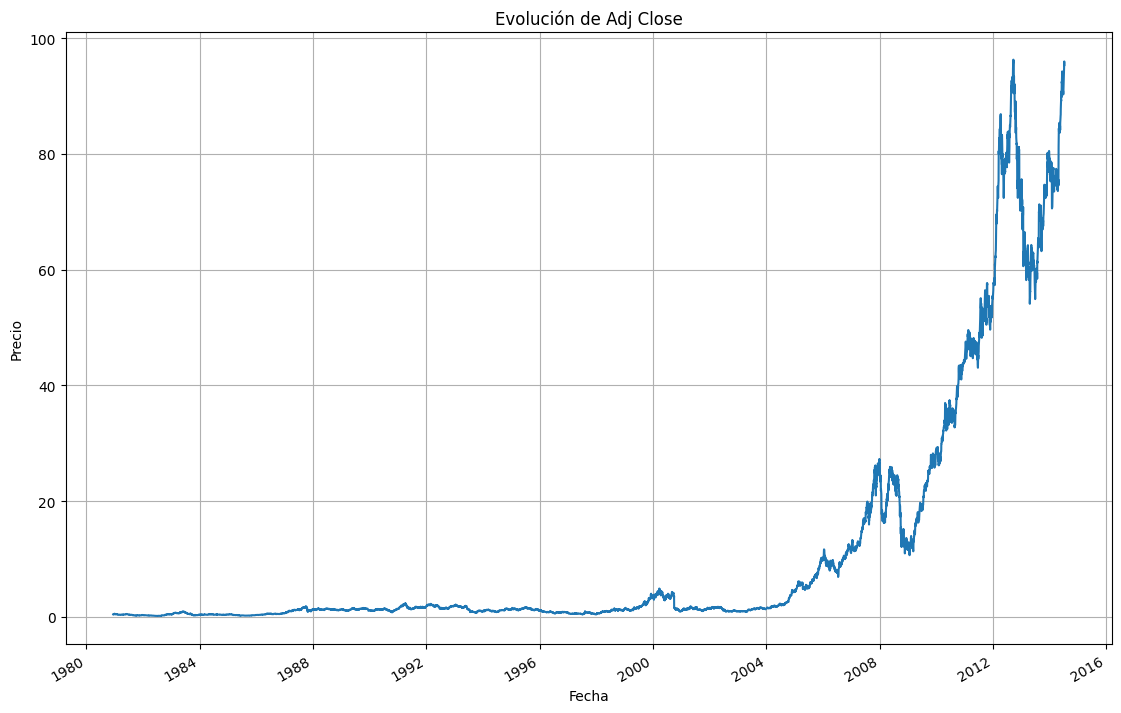

In [16]:
import matplotlib.pyplot as plt

# Graficar la columna 'Adj Close'
apple['Adj Close'].plot(figsize=(13.5, 9))

# Añadir títulos para que sea más claro
plt.title('Evolución de Adj Close')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)

# Mostrar el gráfico
plt.show()